# FER-2013 HOG + Linear SVM

This notebook downloads the FER-2013 dataset from Kaggle, trains a HOG + linear SVM classifier, and then predicts the emotion for a local image. 
It includes the pipeline steps : detect faces, crop/align, resize 48x48, classify. 


The fitted models are saved to `models/fer_hog_svm.joblib` so this notebook can be used without retraining every time.

## Requirements
- `pip install -U numpy pandas scikit-image scikit-learn pillow kagglehub "opencv-python<5"`


In [ ]:
# there is no Haar Cascades on opencv 5 so stay on 4.x
%pip install -q numpy pandas scikit-image scikit-learn pillow kagglehub "opencv-python<5"

Note: you may need to restart the kernel to use updated packages.


# Downloading the dataset

In [ ]:
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path('data')
# Fitted models are saved here and reloaded on later runs; delete to retrain from scratch
MODEL_PATH = Path('models/fer_hog_svm.joblib')

if MODEL_PATH.exists():
    print(f'Found saved model at {MODEL_PATH}, skipping the dataset download.')
else:
    DATA_DIR.mkdir(exist_ok=True)
    try:
        import kagglehub

        print('Using kagglehub download...')
        download_dir = kagglehub.dataset_download('msambare/fer2013')
        print('kagglehub dataset path:', download_dir)

        source_dir = Path(download_dir)
        for item in source_dir.iterdir():
            target = DATA_DIR / item.name
            if target.exists():
                if target.is_dir():
                    shutil.rmtree(target)
                else:
                    target.unlink()
            if item.is_dir():
                shutil.copytree(item, target, dirs_exist_ok=True)
            else:
                shutil.copy2(item, target)

        print('Downloaded and extracted to:', DATA_DIR)
    except Exception as e:
        raise RuntimeError(f'kagglehub download failed: {e}') from e

    print('Dataset files:')
    print(sorted(p.name for p in DATA_DIR.iterdir()))

Found saved model at models/fer_hog_svm.joblib, skipping the dataset download.


# HOG

In [25]:
from PIL import Image
from skimage.feature import hog

EMOTION_LABELS = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}
LABEL_IDS = {name.lower(): idx for idx, name in EMOTION_LABELS.items()}

# The dataset ships as 48x48 grayscale JPGs: data/{train,test}/<emotion>/*.jpg
def load_split(split_dir):
    images, labels = [], []
    for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        label = LABEL_IDS[class_dir.name]
        for img_path in sorted(class_dir.glob('*.jpg')):
            images.append(np.asarray(Image.open(img_path).convert('L'), dtype=np.float32))
            labels.append(label)
    return images, np.array(labels, dtype=np.int64)

def image_to_hog(img):
    return hog(
        img.astype(np.float32),
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True,
        channel_axis=None
    )

# Training the model

In [ ]:
import joblib
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

if MODEL_PATH.exists():
    models = joblib.load(MODEL_PATH)
    clf, prob_clf = models['clf'], models['prob_clf']
    print('Loaded models from', MODEL_PATH)
else:
    train_images, y_train = load_split(DATA_DIR / 'train')
    test_images, y_test = load_split(DATA_DIR / 'test')
    print('Train images:', len(train_images), '\nTest images:', len(test_images))

    print("Converting dataset images to HOG features...")
    X_train = np.stack([image_to_hog(img) for img in train_images]).astype(np.float32)
    X_test = np.stack([image_to_hog(img) for img in test_images]).astype(np.float32)
    print('Done. HOG feature size:', X_train.shape[1])

    clf = LinearSVC(C=1.0, class_weight='balanced', dual=False, random_state=42, max_iter=5000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'Test accuracy: {acc:.4f}')

    # LinearSVC only outputs decision scores, so calibrate it:
    prob_clf = CalibratedClassifierCV(clf, method='sigmoid', cv=3, ensemble=False, n_jobs=-1)
    prob_clf.fit(X_train, y_train)
    print(f'Calibrated test accuracy: {accuracy_score(y_test, prob_clf.predict(X_test)):.4f}')

    MODEL_PATH.parent.mkdir(exist_ok=True)
    joblib.dump({'clf': clf, 'prob_clf': prob_clf}, MODEL_PATH)
    print('Saved models to', MODEL_PATH)

print('Classes:', clf.classes_)

Loaded models from models/fer_hog_svm.joblib
Classes: [0 1 2 3 4 5 6]


In [ ]:
from PIL import Image

def preprocess_local_image(path):
    img = Image.open(path).convert('L')
    img = img.resize((48, 48))
    gray = np.asarray(img, dtype=np.float32)
    return image_to_hog(gray)

def predict_emotion(image_path, model, labels):
    feature = preprocess_local_image(image_path)
    pred_idx = model.predict(feature.reshape(1, -1))[0]
    return labels[pred_idx]

# Example usage:
# Replace this with your own path to a local image and run the cell.
# example_path = '/path/to/your/image.jpg'
# print('Predicted emotion:', predict_emotion(example_path, clf, EMOTION_LABELS))

## Face detection pipeline

For regular photos (not pre-cropped faces): detect faces with an OpenCV Haar cascade, then crop and align (rotate so the eyes are level), resize to 48×48 -> HOG + SVM inference -> display label, confidence and latency in ms.

`LinearSVC` only outputs decision scores, so confidence comes from the calibrated copy `prob_clf` (Platt scaling on cross-validation folds) trained and saved alongside `clf` above.

In [ ]:
import time

import cv2
from IPython.display import display

cv2.ocl.setUseOpenCL(False)

FACE_CASCADE = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
EYE_CASCADE = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

def detect_faces(gray, max_side=640):
    
    """Detect on a copy downscaled to max_side: faster, and fewer false positives on big photos."""
    scale = min(1.0, max_side / max(gray.shape))
    small = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA) if scale < 1 else gray
    boxes = FACE_CASCADE.detectMultiScale(small, scaleFactor=1.1, minNeighbors=5, minSize=(48, 48))
    return [tuple(int(v / scale) for v in box) for box in boxes]

def align_face(gray, box, max_angle=30):
    """Crop the face box, rotated around its center so the eyes are level (when both are found)."""
    x, y, w, h = box
    eyes = EYE_CASCADE.detectMultiScale(gray[y:y + h // 2, x:x + w], scaleFactor=1.1, minNeighbors=5)
    if len(eyes) >= 2:
        # keep the two largest detections, ordered left to right
        eyes = sorted(sorted(eyes, key=lambda e: e[2] * e[3])[-2:], key=lambda e: e[0])
        (lx, ly), (rx, ry) = [(ex + ew / 2, ey + eh / 2) for ex, ey, ew, eh in eyes]
        angle = np.degrees(np.arctan2(ry - ly, rx - lx))
        if rx - lx > w / 5 and abs(angle) <= max_angle:
            # shift the rotation so warpAffine only renders the face box, not the whole image
            M = cv2.getRotationMatrix2D((x + w / 2, y + h / 2), angle, 1.0)
            M[:, 2] -= (x, y)
            return cv2.warpAffine(gray, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    return gray[y:y + h, x:x + w]

def classify_face(face):
    face48 = cv2.resize(face, (48, 48), interpolation=cv2.INTER_AREA)
    probs = prob_clf.predict_proba(image_to_hog(face48).reshape(1, -1))[0]
    best = probs.argmax()
    return EMOTION_LABELS[prob_clf.classes_[best]], float(probs[best])

def run_pipeline(bgr):
    """Detect -> align -> resize -> classify every face in a BGR image."""
    t0 = time.perf_counter()
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    boxes = detect_faces(gray)
    detect_ms = (time.perf_counter() - t0) * 1000
    faces = []
    for box in boxes:
        t1 = time.perf_counter()
        label, conf = classify_face(align_face(gray, box))
        faces.append({'box': box, 'label': label, 'confidence': conf,
                      'ms': (time.perf_counter() - t1) * 1000})
    total_ms = (time.perf_counter() - t0) * 1000
    return faces, detect_ms, total_ms

def put_label(img, text, x, y, color, scale, thickness):
    """Draw black text on a filled box whose bottom-left corner is (x, y), kept inside the image."""
    (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, scale, thickness)
    x = max(0, min(x, img.shape[1] - tw))
    y = max(y, th + baseline)
    cv2.rectangle(img, (x, y - th - baseline), (x + tw, y), color, cv2.FILLED)
    cv2.putText(img, text, (x, y - baseline), cv2.FONT_HERSHEY_SIMPLEX, scale, (0, 0, 0), thickness, cv2.LINE_AA)

def draw_results(bgr, faces, total_ms):
    out = bgr.copy()
    scale = max(max(out.shape[:2]) / 800, 0.6)  # keep text readable on large photos
    thickness = max(1, round(2 * scale))
    for f in faces:
        x, y, w, h = f['box']
        cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), thickness)
        put_label(out, f"{f['label']} {f['confidence']:.0%}", x, y, (0, 255, 0), scale, thickness)
    put_label(out, f'{total_ms:.1f} ms', 0, 0, (255, 255, 255), scale, thickness)
    return out

def show_emotions(image):
    """image: a BGR array (as returned by cv2.imread) or a path to an image file."""
    bgr = cv2.imread(str(image)) if isinstance(image, (str, Path)) else image
    if bgr is None:
        raise FileNotFoundError(image)
    faces, detect_ms, total_ms = run_pipeline(bgr)
    print(f'{len(faces)} face(s) | detection {detect_ms:.1f} ms | total {total_ms:.1f} ms')
    for f in faces:
        print(f"  {f['label']:<8} {f['confidence']:6.1%}  ({f['ms']:.1f} ms align + inference)")
    display(Image.fromarray(cv2.cvtColor(draw_results(bgr, faces, total_ms), cv2.COLOR_BGR2RGB)))

1 face(s) | detection 17.4 ms | total 20.8 ms
  Happy     69.6%  (3.3 ms align + inference)


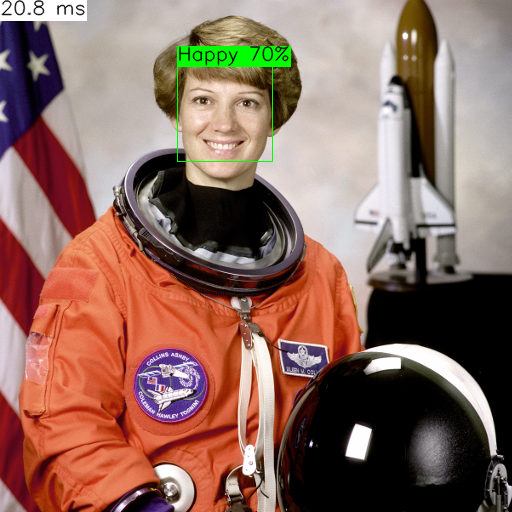

1 face(s) | detection 11.7 ms | total 13.3 ms
  Neutral   33.5%  (1.6 ms align + inference)


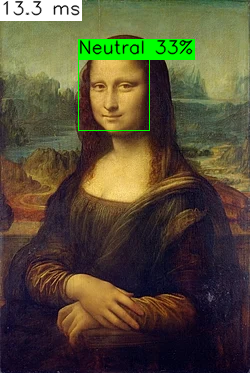

1 face(s) | detection 14.8 ms | total 19.5 ms
  Sad       32.8%  (4.7 ms align + inference)


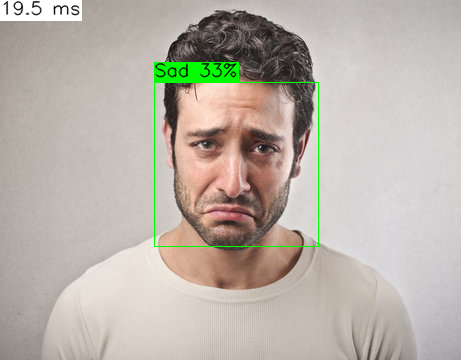

1 face(s) | detection 8.2 ms | total 10.3 ms
  Surprise  45.0%  (2.1 ms align + inference)


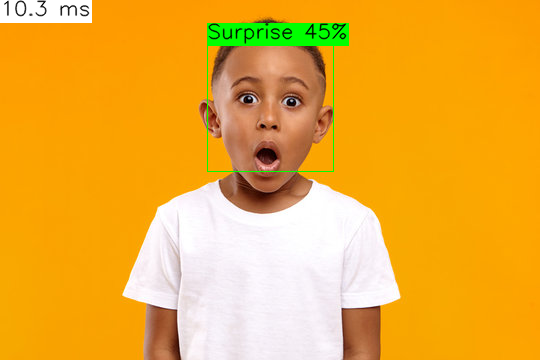

In [ ]:
from skimage import data

astronaut = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR)

show_emotions(astronaut)
# Some images downloaded from the web:
show_emotions('monalisa.webp')
show_emotions('sad.jpg')
show_emotions('surprised.jpg')

## Notes

- `predict_emotion` expects an already-cropped face; use `show_emotions` for regular photos (it detects and aligns faces first).
- The Haar cascade only finds roughly frontal faces; profile or strongly tilted faces may be missed, and performance drops for them anyway.
- Detection runs on a copy downscaled to 640 px, so faces smaller than ~1/13 of the photo's long side are skipped. For group photos with small faces, raise `max_side` in `detect_faces` (slower, more false positives).
- Confidence comes from a sigmoid-calibrated SVM, so treat it as a rough probability, not a guarantee.